**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score,confusion_matrix,classification_report
import pickle

**Loading and Understanding dataset**

In [3]:
# Load the data
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [4]:
df.shape

(7043, 21)

In [5]:
df.head(6)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
# Drop column
df.drop('customerID', axis=1, inplace=True)

In [8]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [9]:
# unique values
numerical_list=["tenure","MonthlyCharges","TotalCharges"]

for col in df.columns:
  if col not in numerical_list:
    print(col,df[col].unique())
    print('-'*50)


gender ['Female' 'Male']
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner ['Yes' 'No']
--------------------------------------------------
Dependents ['No' 'Yes']
--------------------------------------------------
PhoneService ['No' 'Yes']
--------------------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity ['No' 'Yes' 'No internet service']
--------------------------------------------------
OnlineBackup ['Yes' 'No' 'No internet service']
--------------------------------------------------
DeviceProtection ['No' 'Yes' 'No internet service']
--------------------------------------------------
TechSupport ['No' 'Yes' 'No internet service']
--------------------------------------------------
StreamingTV ['No' 'Yes' 'No internet 

In [10]:
print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [11]:
df[df['TotalCharges']==" "]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [12]:
df['TotalCharges']=df['TotalCharges'].replace({" ":"0.0"})

In [13]:
df = df[df['TotalCharges'] != 0.0]

In [14]:
df['TotalCharges']=df['TotalCharges'].astype(float)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [16]:
#Checking target column

print(df['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


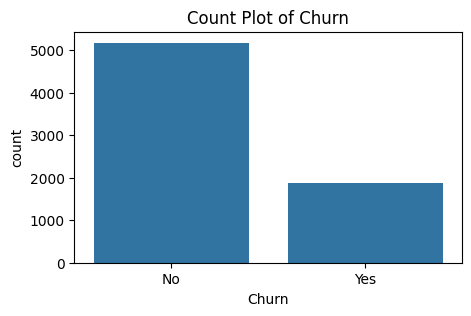

In [17]:
plt.figure(figsize=(5, 3))
sns.countplot(x=df['Churn'])
plt.title('Count Plot of Churn')
plt.show()

Cleaned the dataset by removing non-informative identifiers and resolving TotalCharges formatting issues to ensure consistent numeric types. This prevents downstream model errors and avoids biased patterns caused by invalid numeric entries. After cleaning, the dataset is suitable for exploratory analysis and modeling.

Insights:
1. Removed customerID as it is not required for modelling
2. No missing values in the dataset
3. Missing values in TotalCharges were replaced by 0
4. Class imbalance identified in the target column


**EDA**

In [18]:
df.shape

(7043, 20)

In [19]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [20]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


**Numerical Features Analysis**

In [21]:
def plot_histogram(df, column_name):
  plt.figure(figsize=(5, 3))
  sns.histplot(df[column_name], kde=True)
  plt.title(f"Distribution of {column_name}")

  # calculate the mean and median values for the columns
  col_mean = df[column_name].mean()
  col_median = df[column_name].median()

  # add vertical lines for mean and median
  plt.axvline(col_mean, color="red", linestyle="--", label="Mean")
  plt.axvline(col_median, color="green", linestyle="-", label="Median")

  plt.legend()

  plt.show()

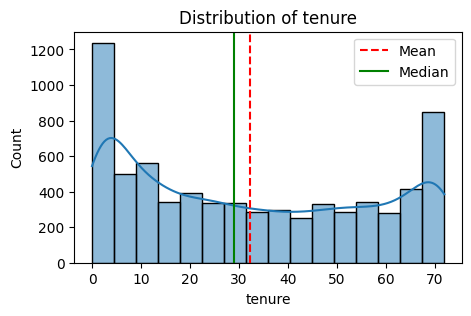

In [22]:
plot_histogram(df, 'tenure')

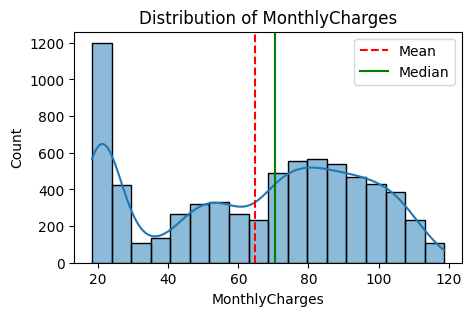

In [23]:
plot_histogram(df,'MonthlyCharges')

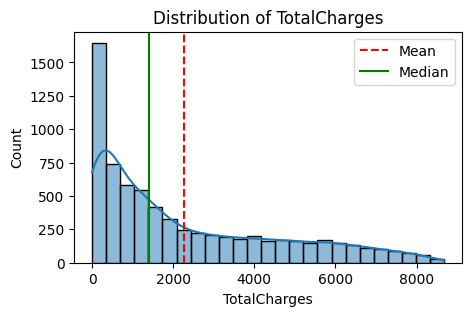

In [24]:
plot_histogram(df,'TotalCharges')

**Box plot for numerical features**

In [25]:
def plot_boxplot(df, column_name):

  plt.figure(figsize=(5, 3))
  sns.boxplot(y=df[column_name])
  plt.title(f"Distribution of {column_name}")
  plt.ylabel(column_name)
  plt.show()

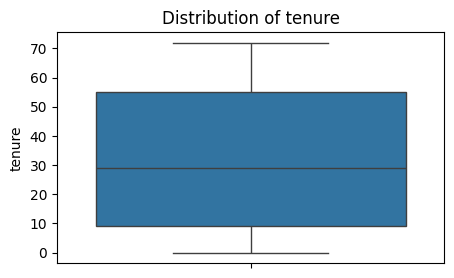

In [26]:
plot_boxplot(df,'tenure')

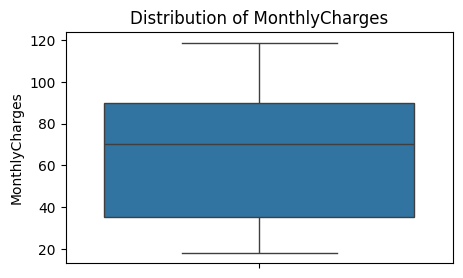

In [27]:
plot_boxplot(df,'MonthlyCharges')

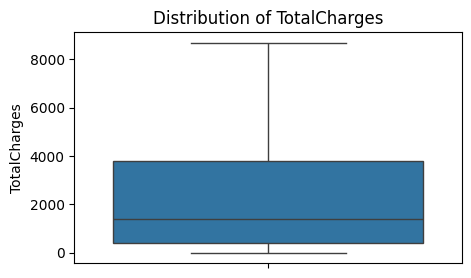

In [28]:
plot_boxplot(df,'TotalCharges')

**Correlation Heatmap for numerical columns**

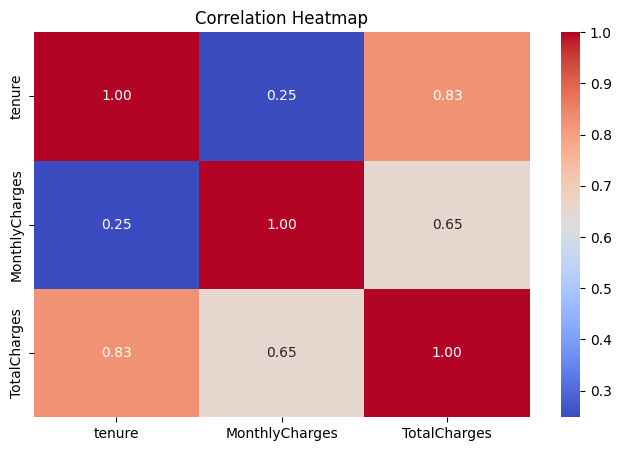

In [29]:
plt.figure(figsize=(8, 5))
sns.heatmap(df[["tenure","MonthlyCharges","TotalCharges"]].corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**Categorical feature Analysis**

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [31]:
object_cols= df.select_dtypes(include='object').columns.to_list()
object_cols = ['SeniorCitizen']+ object_cols
object_cols

['SeniorCitizen',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

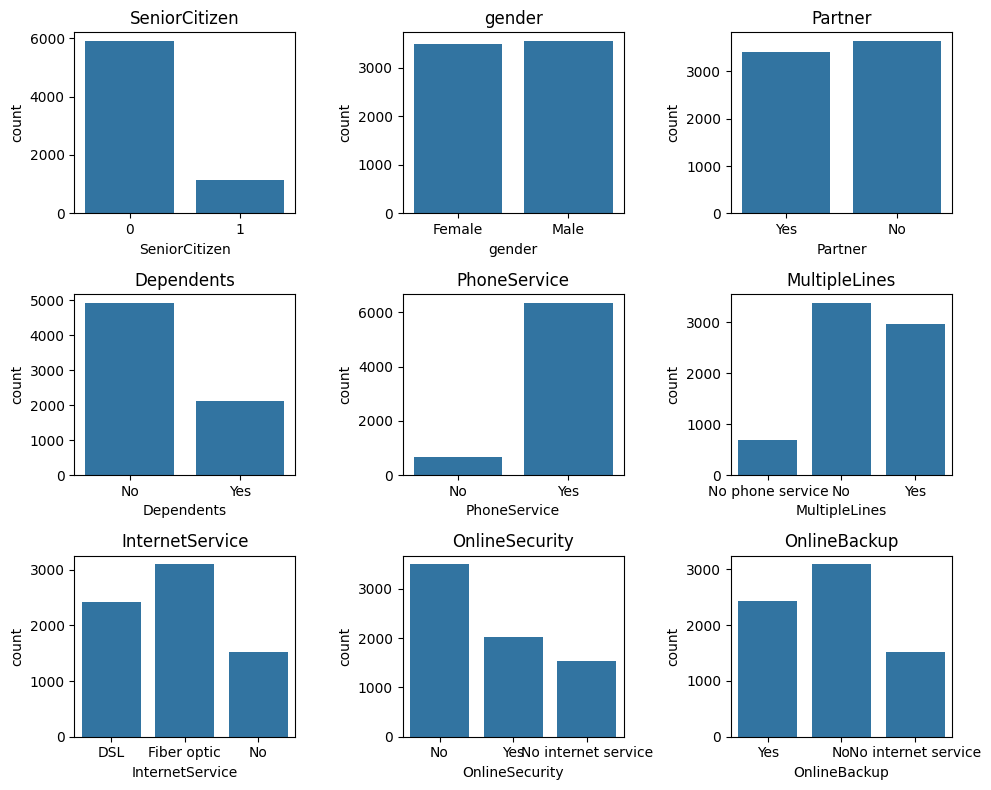

In [32]:
plt.figure(figsize=(10,8))

for i, col in enumerate(object_cols[:9]):
    plt.subplot(3,3,i+1)
    sns.countplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

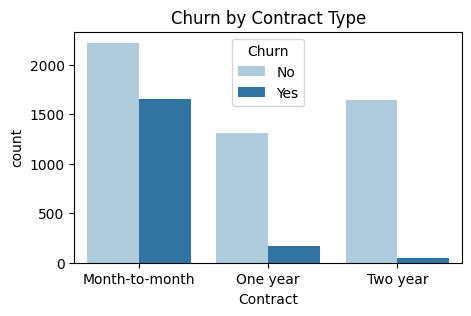

In [33]:
plt.figure(figsize=(5,3))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Paired')
plt.title('Churn by Contract Type')
plt.show()

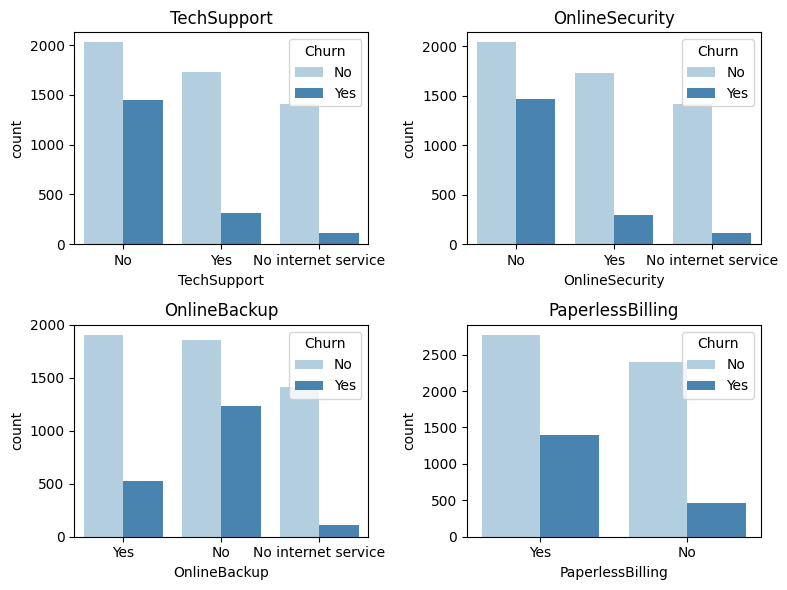

In [34]:
fig , ax = plt.subplots(2,2,figsize=(8,6))
sns.countplot(data=df , x='TechSupport',hue='Churn',palette='Blues',ax=ax[0,0])
ax[0,0].set_title('TechSupport')
sns.countplot(data=df , x='OnlineSecurity',hue='Churn',palette='Blues',ax=ax[0,1])
ax[0,1].set_title('OnlineSecurity')
sns.countplot(data=df , x='OnlineBackup',hue='Churn',palette='Blues',ax=ax[1,0])
ax[1,0].set_title('OnlineBackup')
sns.countplot(data=df , x='PaperlessBilling',hue='Churn',palette='Blues',ax=ax[1,1])
ax[1,1].set_title('PaperlessBilling')
plt.tight_layout()
plt.show()

Explored churn patterns across numeric and categorical features to identify potential drivers (e.g., tenure, monthly charges, contract type). EDA helps verify data reasonableness, detect skew/outliers, and generate hypotheses about churn behavior that guide feature handling and modeling choices.

**Data Preprocessing**

In [35]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Label encoding of target column

In [36]:
df['Churn']=df['Churn'].replace({"Yes":1,"No":0})

/tmp/ipykernel_3863/1419440389.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn']=df['Churn'].replace({"Yes":1,"No":0})


In [37]:
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


Label Encoding for categorical features

In [38]:
 #identify columns with object data types
 object_columns= df.select_dtypes(include='object').columns.to_list()

In [39]:
print(object_columns)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [40]:
#dictinory to save encoders
encoders = {}

# apply label encoding and store the encoders
for col in object_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

#save the encoders to pickle file
with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)


In [41]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

In [42]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


**Training and test data split**

In [43]:
#splitting the features and target
x=df.drop('Churn',axis=1)
y=df['Churn']

In [44]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [45]:
x = pd.get_dummies(x, drop_first=True)

In [46]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [47]:
print(y_train.shape)

(5634,)


In [48]:
print(y_train.value_counts())

Churn
0    4138
1    1496
Name: count, dtype: int64


Split data into training and test sets to evaluate generalization on unseen customers. Standardization was applied for Logistic Regression to stabilize optimization and make coefficients comparable across features. Tree-based models were kept unscaled since splitting rules are scale-invariant.

**Model Training and Evaluation**

Training with default hyperparameters

In [49]:
models = {LogisticRegression(random_state=42): 'Logistic Regression',
          DecisionTreeClassifier(class_weight="balanced",random_state=42): 'Decision Tree',
          RandomForestClassifier(class_weight="balanced",random_state=42): 'Random Forest'}

In [50]:
from sklearn.model_selection import cross_val_score

# perform 5-fold cross validation for each model
for model_obj, model_name in models.items():
  scores = cross_val_score(model_obj, x_train, y_train, cv=5, scoring="accuracy")
  print(f"{model_name} cross-validation accuracy: {scores.mean():.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Logistic Regression cross-validation accuracy: 0.7954
Decision Tree cross-validation accuracy: 0.7281
Random Forest cross-validation accuracy: 0.7898


Logistic Regression

In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [52]:
log_model=LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(x_train_scaled,y_train)
y_pred_log=log_model.predict(x_test_scaled)

In [53]:
print("Logistic Regression Model:")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print('/nClassification Report:')
print(classification_report(y_test, y_pred_log))

Logistic Regression Model:
Accuracy: 0.815471965933286
/nClassification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



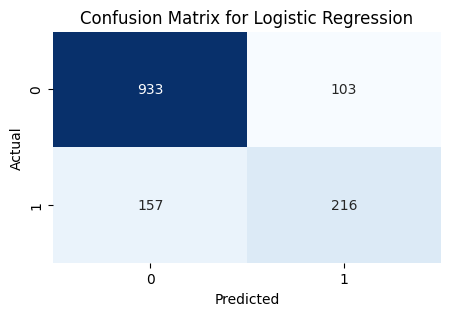

In [54]:
cm = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

Decision Tree

In [55]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    class_weight="balanced",
    criterion="entropy",
    max_depth=3,
    min_samples_leaf=40,
    min_samples_split=60,
    random_state=42
)

dt_model.fit(x_train, y_train)
y_pred_dt = dt_model.predict(x_test)

In [56]:
print("Decision Tree Model")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

Decision Tree Model
Accuracy: 0.7402413058907026

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1036
           1       0.51      0.76      0.61       373

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.75      1409



In [57]:
confusion_matrix(y_test, y_pred_dt)

array([[758, 278],
       [ 88, 285]])

Random Forest

In [58]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(x_train, y_train)

# thresholding like the .ipynb (0.35)
y_prob_rf = rf_model.predict_proba(x_test)[:, 1]
y_pred_rf = (y_prob_rf >= 0.35).astype(int)

In [59]:
print("Random Forest Model (threshold=0.35)")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Model (threshold=0.35)
Accuracy: 0.7217885024840313

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.67      0.78      1036
           1       0.49      0.87      0.62       373

    accuracy                           0.72      1409
   macro avg       0.71      0.77      0.70      1409
weighted avg       0.82      0.72      0.74      1409



In [60]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_rf)

array([[693, 343],
       [ 49, 324]])

Feature Importance

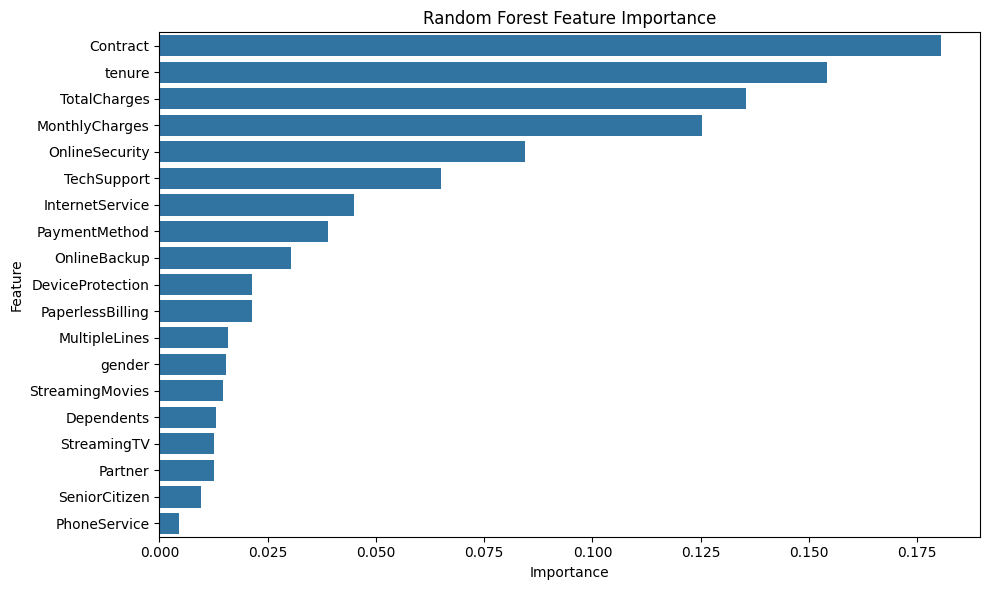

In [61]:
feature_importances = pd.DataFrame({'feature': x_train.columns, 'importance': rf_model.feature_importances_})
feature_importances = feature_importances.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importances)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Trained multiple models to compare baseline behavior and then tuned key hyperparameters for the best-performing candidates.

**Advanced Model Evaluation**

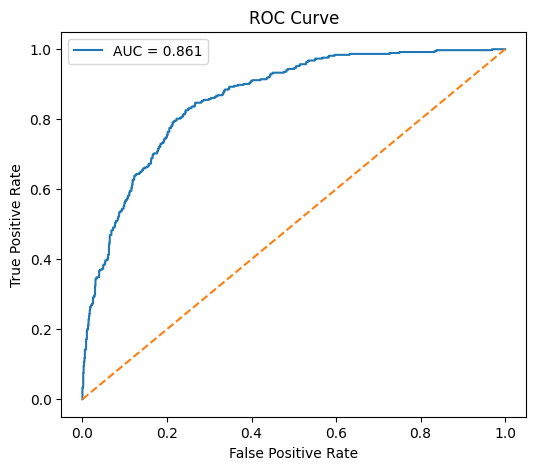

AUC Score: 0.8607308476611426


In [62]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = rf_model.predict_proba(x_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", auc_score)

Precision Recall Curve

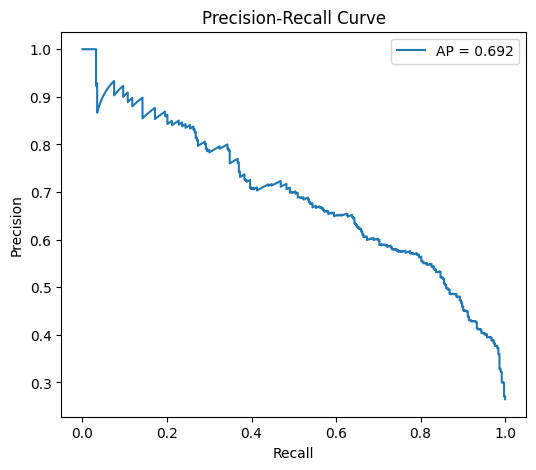

Average Precision: 0.6920094278105434


In [63]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds_pr = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"AP = {ap_score:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

print("Average Precision:", ap_score)

Computed ROC-AUC and Precision–Recall curves to assess discrimination across all thresholds rather than at a single cutoff. ROC-AUC captures ranking quality, while PR-focused metrics better reflect minority-class performance. This strengthens evaluation beyond accuracy in imbalanced churn prediction.

Threshold Comparison

In [64]:
from sklearn.metrics import classification_report

for th in [0.5, 0.4, 0.35]:
    y_pred_th = (y_prob >= th).astype(int)
    print(f"\nThreshold = {th}")
    print(classification_report(y_test, y_pred_th))


Threshold = 0.5
              precision    recall  f1-score   support

           0       0.90      0.80      0.85      1036
           1       0.58      0.74      0.65       373

    accuracy                           0.79      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.81      0.79      0.80      1409


Threshold = 0.4
              precision    recall  f1-score   support

           0       0.93      0.72      0.81      1036
           1       0.52      0.85      0.65       373

    accuracy                           0.75      1409
   macro avg       0.73      0.78      0.73      1409
weighted avg       0.82      0.75      0.77      1409


Threshold = 0.35
              precision    recall  f1-score   support

           0       0.93      0.67      0.78      1036
           1       0.49      0.87      0.62       373

    accuracy                           0.72      1409
   macro avg       0.71      0.77      0.70      1409
weighted avg       0.8

In [65]:
top_percent = 0.35

cutoff = np.percentile(y_prob, 100*(1-top_percent))
selected = y_prob >= cutoff

captured_churn = y_test[selected].sum()
total_churn = y_test.sum()

print("Churn captured in top 35%:", captured_churn / total_churn)

Churn captured in top 35%: 0.7613941018766756


**Result**

The final Random Forest model was selected due to its strong churn detection capability under class imbalance. Using a tuned probability threshold (0.35), the model achieved approximately 72% accuracy while maintaining high churn recall (0.87), meaning it successfully captures most true churners for proactive retention. Precision is lower, reflecting a deliberate tradeoff to prioritize identifying at-risk customers over minimizing false positives. ROC-AUC (0.86) indicates strong ranking ability, and PR-based evaluation further supports robustness for imbalanced churn prediction.

**Business Recommendations**

Target retention outreach by risk score (top deciles): Focus offers/calls on the top ~20–35% highest predicted churn probabilities to capture most churners while controlling operational cost.

Contract strategy: If month-to-month contract is a top driver, prioritize incentives to move customers to longer-term contracts.

Price/charge sensitivity: If monthly charges/total charges contribute strongly, test tiered discounts or bundled plans for high-charge segments.

Tenure-based interventions: If churn is highest at low tenure, deploy early-life onboarding programs (first 30–90 days) and proactive support to reduce early churn.

In [69]:
import pickle
import pandas as pd
from google.colab import files
from sklearn.preprocessing import StandardScaler

# ---- STEP 1: Retrain and save everything ----

# Clean the data exactly like you did before
df2 = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Drop customerID
df2.drop('customerID', axis=1, inplace=True)

# Fix TotalCharges
df2['TotalCharges'] = df2['TotalCharges'].replace({" ": "0.0"})
df2 = df2[df2['TotalCharges'] != 0.0]
df2['TotalCharges'] = df2['TotalCharges'].astype(float)

# Encode Churn
df2['Churn'] = df2['Churn'].replace({"Yes": 1, "No": 0})

# Encode all object columns
from sklearn.preprocessing import LabelEncoder
object_columns = df2.select_dtypes(include='object').columns.to_list()
encoders2 = {}
for col in object_columns:
    le = LabelEncoder()
    df2[col] = le.fit_transform(df2[col])
    encoders2[col] = le

# Split features and target
x2 = df2.drop('Churn', axis=1)
y2 = df2['Churn']

# Scale
scaler2 = StandardScaler()
x2_scaled = scaler2.fit_transform(x2)

# Train Random Forest
from sklearn.ensemble import RandomForestClassifier
rf_model2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_model2.fit(x2, y2)
print("✅ Model trained!")

# ---- STEP 2: Save model and scaler ----
with open('churn_model.pkl', 'wb') as f:
    pickle.dump(rf_model2, f)
print("✅ Model saved!")

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler2, f)
print("✅ Scaler saved!")

# ---- STEP 3: Add risk scores to data ----
df2['churn_probability'] = rf_model2.predict_proba(x2)[:, 1]
df2['risk_tier'] = pd.cut(
    df2['churn_probability'],
    bins=[0, 0.35, 0.65, 1.0],
    labels=['Low', 'Medium', 'High']
)
df2.to_csv('churn_scored.csv', index=False)
print("✅ Scored data saved!")

# ---- STEP 4: Download all files ----
files.download('churn_model.pkl')
files.download('scaler.pkl')
files.download('churn_scored.csv')
print("✅ All files downloading!")

/tmp/ipykernel_3863/4036786091.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2['Churn'] = df2['Churn'].replace({"Yes": 1, "No": 0})


✅ Model trained!
✅ Model saved!
✅ Scaler saved!
✅ Scored data saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloading!
